In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [29]:
x_train = pd.read_csv('../data/x_train.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel()

---

#### Validação Cruzada K-Fold

In [30]:
# 1. Listas para armazenar os 30 resultados médios
results = {
    'Decision Tree': [],
    'Random Forest': [],
    'Logistic Regression': [],
    'SVM': [],
    'KNN': []
}

# 2. Validação Cruzada com 30 testes, 10 splits
for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    models = [
        ('Decision Tree', DecisionTreeClassifier(criterion='entropy')),
        ('Random Forest', RandomForestClassifier(n_estimators=100)),
        ('Logistic Regression', LogisticRegression(max_iter=1000)),
        ('SVM', SVC()),
        ('KNN', KNeighborsClassifier())
    ]

    for name, model in models:
        scores = cross_val_score(model, x_train, y_train, cv=kfold)
        results[name].append(scores.mean())

# 3. Exibir a média de cada modelo
print("\nRESULTADOS DA VALIDAÇÃO CRUZADA\n")
for name in results:
    mean = np.mean(results[name])
    deviation = np.std(results[name])
    print(f"{name}: {mean*100:.2f}% (Desvio Padrão: {deviation*100:.2f}%)")


RESULTADOS DA VALIDAÇÃO CRUZADA

Decision Tree: 79.28% (Desvio Padrão: 0.68%)
Random Forest: 80.81% (Desvio Padrão: 0.47%)
Logistic Regression: 82.03% (Desvio Padrão: 0.22%)
SVM: 83.32% (Desvio Padrão: 0.12%)
KNN: 79.62% (Desvio Padrão: 0.52%)


Serão escolhidos os 3 melhores modelos: Random Forest, Logistic Regression e SVM.

---

#### GridSearchCV
Aplicaremos o GridSearchCV para descobrir os melhores parâmetros para cada algoritmo.

##### **Random Forest**

Os valores encontrados para o Random Forest foram: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 100}

In [31]:
from sklearn.model_selection import GridSearchCV

params_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

grid_rf = GridSearchCV(RandomForestClassifier(), params_rf, cv=5, n_jobs=-1, verbose=1)
grid_rf.fit(x_train, y_train)

print(f"Melhor Random Forest: {grid_rf.best_score_:.6f}")
print(f"Parâmetros: {grid_rf.best_params_}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Melhor Random Forest: 0.837267
Parâmetros: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [32]:
from sklearn.model_selection import GridSearchCV

params_rf_refined= {
    'n_estimators': [100, 150, 200],
    'max_depth': [9, 10, 11, 12],
    'min_samples_split': [4, 5, 6],
    'min_samples_leaf': [4, 5, 6],
    'criterion': ['gini', 'entropy']
}

grid_rf = GridSearchCV(RandomForestClassifier(), params_rf_refined, cv=5, n_jobs=-1, verbose=1)
grid_rf.fit(x_train, y_train)

print(f"Melhor Random Forest: {grid_rf.best_score_:.6f}")
print(f"Parâmetros: {grid_rf.best_params_}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Melhor Random Forest: 0.838384
Parâmetros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}


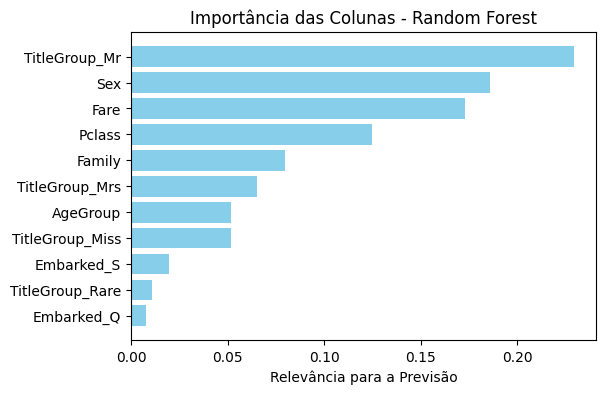

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Pega as importâncias do melhor modelo encontrado
importance = grid_rf.best_estimator_.feature_importances_
columns = x_train.columns

# Cria um gráfico organizado
feature_df = pd.DataFrame({'Feature': columns, 'Importance': importance})
feature_df = feature_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(6, 4))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='skyblue')
plt.title('Importância das Colunas - Random Forest')
plt.xlabel('Relevância para a Previsão')
plt.show()

##### **Logistic Regression**

Os valores encontrados para a Regressão Logística foram: {logreg__C: 1.0, poly__degree: 2}

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

params_lr = {
    'tol': [0.0001, 0.00001, 0.000001],
    'C': [1.0, 1.5, 2.0, 5.0],
    'solver': ['lbfgs', 'sag', 'saga'],
    'max_iter': [1000]
}

grid_lr = GridSearchCV(LogisticRegression(), params_lr, cv=5, n_jobs=-1, verbose=1)
grid_lr.fit(x_train, y_train)

print(f"Melhor Regressão Logística: {grid_lr.best_score_:.6f}")
print(f"Parâmetros: {grid_lr.best_params_}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Melhor Regressão Logística: 0.826031
Parâmetros: {'C': 2.0, 'max_iter': 1000, 'solver': 'saga', 'tol': 0.0001}


In [35]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),            
    ('logreg', LogisticRegression(max_iter=2000))
])

param_grid_poly = {
    'logreg__C': [0.1, 1.0, 10.0],
    'poly__degree': [2] 
}

grid_poly = GridSearchCV(pipe, param_grid_poly, cv=5, n_jobs=-1)
grid_poly.fit(x_train, y_train)

print(f"Melhor Regressão Logística: {grid_poly.best_score_:.6f}")
print("\nParâmetros:")
for param, value in grid_poly.best_params_.items():
    print(f"- {param}: {value}")

Melhor Regressão Logística: 0.828316

Parâmetros:
- logreg__C: 1.0
- poly__degree: 2


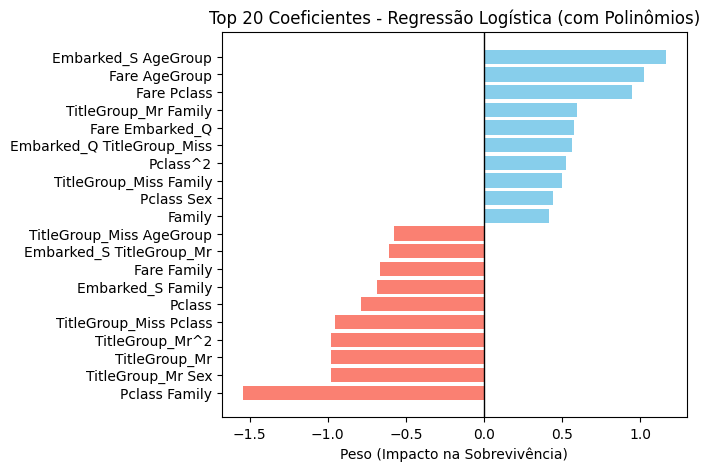

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Extração dos dados (usando o melhor pipeline)
best_pipe = grid_poly.best_estimator_
model_lr = best_pipe.named_steps['logreg']
poly_transformer = best_pipe.named_steps['poly']

column_name = poly_transformer.get_feature_names_out(x_train.columns)

df_weight = pd.DataFrame({
    'Feature': column_name,
    'Coefficient': model_lr.coef_[0]
})

# Pegar os 5 mais positivos e 5 mais negativos
top_positive = df_weight.sort_values(by='Coefficient', ascending=False).head(10)
top_negative = df_weight.sort_values(by='Coefficient', ascending=False).tail(10)
top_total = pd.concat([top_positive, top_negative]).sort_values(by='Coefficient')

plt.figure(figsize=(6, 5))
colors = ['salmon' if c < 0 else 'skyblue' for c in top_total['Coefficient']]
plt.barh(top_total['Feature'], top_total['Coefficient'], color=colors)
plt.axvline(0, color='black', lw=1)
plt.title('Top 20 Coeficientes - Regressão Logística (com Polinômios)')
plt.xlabel('Peso (Impacto na Sobrevivência)')
plt.show()

##### **Suport Vector Machine - SVM**

Os valores encontrados para o SVM foram: {'C': 150, 'gamma': 0.01, 'kernel': 'rbf'} 

In [37]:
from sklearn.model_selection import GridSearchCV

params_svm = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 1, 0.1, 0.01, 0.001]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10],
        'degree': [2, 3],
        'gamma': ['scale', 0.1]
    }
]

grid_svm = GridSearchCV(SVC(), params_svm, cv=5, n_jobs=-1, verbose=1)
grid_svm.fit(x_train, y_train)

print(f"Melhor SVM: {grid_svm.best_score_:.6f}")
print(f"Parâmetros: {grid_svm.best_params_}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Melhor SVM: 0.838365
Parâmetros: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


In [38]:
params_svm_refined = {
    'C': [150, 200, 300, 500], 
    'gamma': [0.008, 0.01, 0.012], 
    'kernel': ['rbf']
}

grid_svm = GridSearchCV(SVC(), params_svm_refined, cv=5, n_jobs=-1, verbose=1)
grid_svm.fit(x_train, y_train)

print(f"Melhor SVM: {grid_svm.best_score_:.6f}")
print(f"Parâmetros: {grid_svm.best_params_}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhor SVM: 0.839489
Parâmetros: {'C': 150, 'gamma': 0.01, 'kernel': 'rbf'}


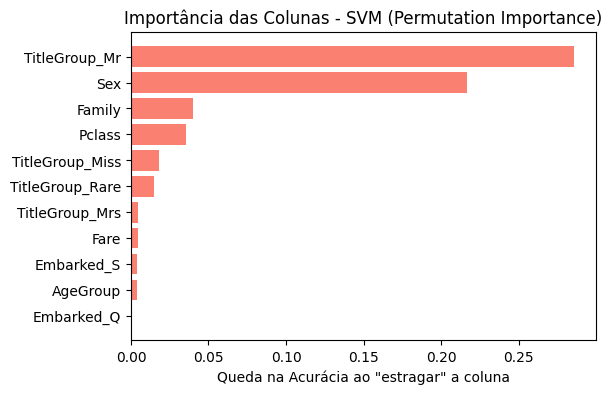

In [39]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

result = permutation_importance(grid_svm.best_estimator_, x_train, y_train, n_repeats=10, random_state=42)

importances = result.importances_mean
columns = x_train.columns
feature_df_svm = pd.DataFrame({'Feature': columns, 'Importance': importances})
feature_df_svm = feature_df_svm.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(6,4))
plt.barh(feature_df_svm['Feature'], feature_df_svm['Importance'], color='salmon')
plt.title('Importância das Colunas - SVM (Permutation Importance)')
plt.xlabel('Queda na Acurácia ao "estragar" a coluna')
plt.show()

---

#### Confusion Matrix

As Matrizes de confusão foram feitas por meio da validação cruzada. 
O SVM tem os melhores indicadores, de acordo com o classification report.

<Figure size 600x400 with 0 Axes>

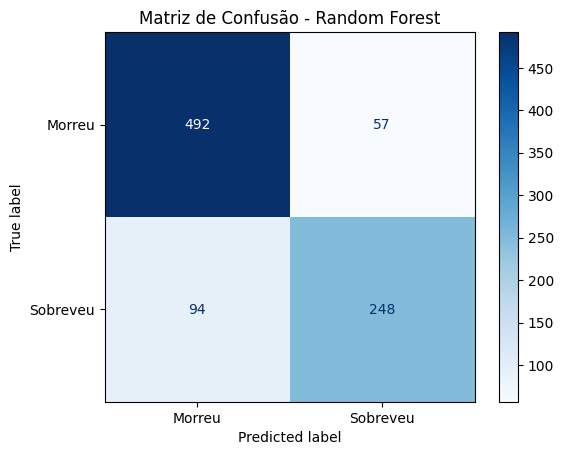

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       549
           1       0.81      0.73      0.77       342

    accuracy                           0.83       891
   macro avg       0.83      0.81      0.82       891
weighted avg       0.83      0.83      0.83       891



In [40]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Escolha o seu melhor modelo (ex: Random Forest)
best_model = grid_rf.best_estimator_

# Gera as previsões "fora da amostra" para o treino
y_train_pred = cross_val_predict(best_model, x_train, y_train, cv=5)

# Plota a Matriz
cm = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay(cm, display_labels=['Morreu', 'Sobreveu']).plot(cmap='Blues')
plt.title('Matriz de Confusão - Random Forest')
plt.show()

from sklearn.metrics import classification_report
print(classification_report(y_train, y_train_pred))

<Figure size 600x400 with 0 Axes>

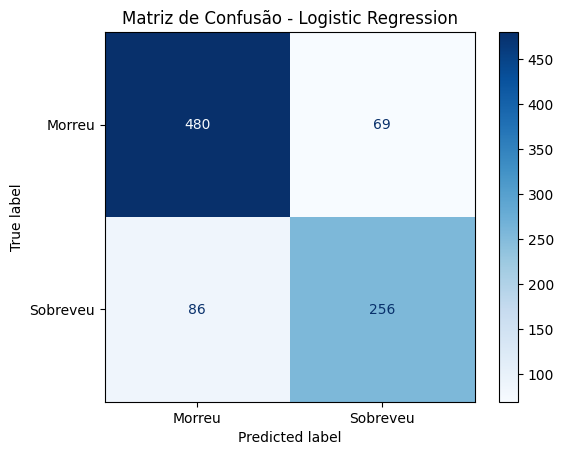

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       549
           1       0.79      0.75      0.77       342

    accuracy                           0.83       891
   macro avg       0.82      0.81      0.81       891
weighted avg       0.82      0.83      0.83       891



In [41]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Escolha o seu melhor modelo (ex: Random Forest)
best_model = grid_lr.best_estimator_

# Gera as previsões "fora da amostra" para o treino
y_train_pred = cross_val_predict(best_model, x_train, y_train, cv=5)

# Plota a Matriz
cm = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay(cm, display_labels=['Morreu', 'Sobreveu']).plot(cmap='Blues')
plt.title('Matriz de Confusão - Logistic Regression')
plt.show()

from sklearn.metrics import classification_report
print(classification_report(y_train, y_train_pred))

<Figure size 600x400 with 0 Axes>

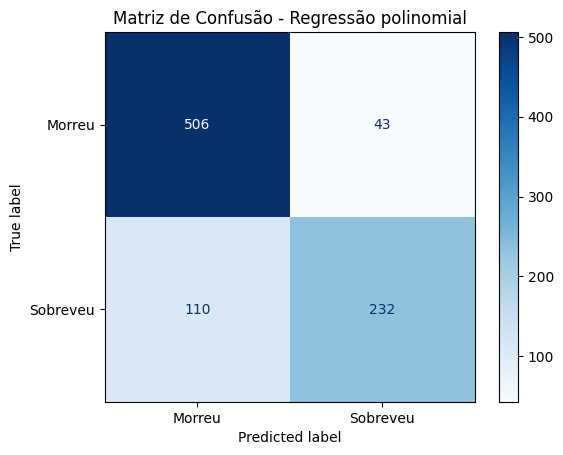

              precision    recall  f1-score   support

           0       0.82      0.92      0.87       549
           1       0.84      0.68      0.75       342

    accuracy                           0.83       891
   macro avg       0.83      0.80      0.81       891
weighted avg       0.83      0.83      0.82       891



In [42]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Escolha o seu melhor modelo (ex: Random Forest)
best_model = grid_poly.best_estimator_

# Gera as previsões "fora da amostra" para o treino
y_train_pred = cross_val_predict(best_model, x_train, y_train, cv=5)

# Plota a Matriz
cm = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay(cm, display_labels=['Morreu', 'Sobreveu']).plot(cmap='Blues')
plt.title('Matriz de Confusão - Regressão polinomial')
plt.show()

from sklearn.metrics import classification_report
print(classification_report(y_train, y_train_pred))

<Figure size 600x400 with 0 Axes>

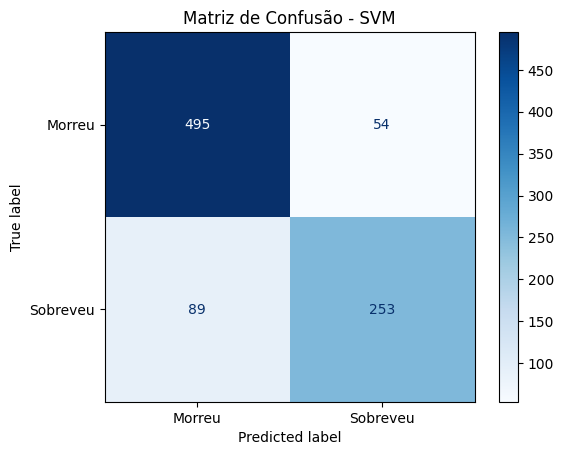

              precision    recall  f1-score   support

           0       0.85      0.90      0.87       549
           1       0.82      0.74      0.78       342

    accuracy                           0.84       891
   macro avg       0.84      0.82      0.83       891
weighted avg       0.84      0.84      0.84       891



In [43]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Escolha o seu melhor modelo (ex: Random Forest)
best_model = grid_svm.best_estimator_

# Gera as previsões "fora da amostra" para o treino
y_train_pred = cross_val_predict(best_model, x_train, y_train, cv=5)

# Plota a Matriz
cm = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay(cm, display_labels=['Morreu', 'Sobreveu']).plot(cmap='Blues')
plt.title('Matriz de Confusão - SVM')
plt.show()

from sklearn.metrics import classification_report
print(classification_report(y_train, y_train_pred))

---
#### Voting Classifier

In [44]:
from sklearn.ensemble import VotingClassifier

best_svm = grid_svm.best_estimator_
best_svm.set_params(probability=True)
best_svm.fit(x_train, y_train)

final_vote = VotingClassifier(
    estimators=[('rf', grid_rf.best_estimator_), ('svm', best_svm)],
    voting='soft'
)

final_vote.fit(x_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('svm', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5


In [50]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

# 1. Gerar predições
y_pred_vote = cross_val_predict(final_vote, x_train, y_train, cv=5)

# 2. Relatório de performance
print("PERFORMANCE DO ENSEMBLE (RF + SVM):")
print(classification_report(y_train, y_pred_vote))

# 3. Gerar matriz de confusão 
cm_vote = confusion_matrix(y_train, y_pred_vote)
print(f"Erros totais do Ensemble: {cm_vote[0,1] + cm_vote[1,0]}")

PERFORMANCE DO ENSEMBLE (RF + SVM):
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       549
           1       0.82      0.70      0.76       342

    accuracy                           0.83       891
   macro avg       0.83      0.80      0.81       891
weighted avg       0.83      0.83      0.82       891

Erros totais do Ensemble: 154


---
Salvando o modelo que será utilizado nas predições:

In [51]:
import joblib

model_path = '../models/ensemble_titanic.joblib'

artefacts = {
    'modelo_final': final_vote,
    'features': x_train.columns.tolist(),
}

joblib.dump(artefacts, model_path)

print(f"Modelo salvo em: {model_path}")

Modelo salvo em: ../models/ensemble_titanic.joblib
